In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "coffee/total-production.csv"



# Coffee Production Stats

* Create a bar chart of the top 10 coffee producers by total production in 'total-production.csv', sorted from highest to lowest. Change the xticks to two letter country abbreviations.


* Data Prep Code

<mark style="background-color: #000000"> coffee_production = pd.read_csv("coffee/total-production.csv").T </mark> 

<mark style="background-color: #000000"> coffee_production.columns = coffee_production.iloc[0] </mark> 

<mark style="background-color: #000000"> coffee_production = coffee_production.drop("total_production") </mark> 


In [9]:
coffee_production = pd.read_csv("total-production.csv").T
coffee_production.columns = coffee_production.iloc[0]
coffee_production = coffee_production.drop("total_production")

coffee_production.head()

total_production,Angola,Bolivia (Plurinational State of),Brazil,Burundi,Ecuador,Indonesia,Madagascar,Malawi,Papua New Guinea,Paraguay,...,Panama,Sierra Leone,Sri Lanka,Thailand,Togo,Trinidad & Tobago,Uganda,Venezuela,Viet Nam,Yemen
1990,50.345,122.777,27285.6286,487.393,1503.815,7441.383,982.447,104.628,962.841,130.627,...,214.987,42.783,95.87,757.017,161.308,14.581,1955.009,1122.477,1310.288,0.0
1991,79.331,103.536,27293.4934,667.199,2123.824,8493.196,932.513,124.286,746.816,79.653,...,192.532,54.379,81.549,1468.936,432.652,17.792,2088.001,940.704,1437.848,0.0
1992,77.52,120.235,34603.3542,620.238,1185.48,5569.478,1121.684,137.161,900.111,54.291,...,196.978,39.084,53.181,1254.945,85.648,14.328,2185.074,1215.298,2340.447,0.0
1993,32.608,50.823,28166.9786,393.354,2069.007,6743.288,441.859,62.111,1019.481,70.046,...,142.066,37.451,53.79,1275.201,194.939,16.079,3141.706,1332.881,3020.216,0.0
1994,76.802,116.944,28192.047,664.143,2375.766,5367.878,641.372,84.112,1138.659,24.689,...,248.313,72.738,42.448,1399.135,176.296,18.435,2392.753,988.996,3631.609,0.0


In [8]:
coffee_production.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 1990 to 2018
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Angola                            29 non-null     object
 1   Bolivia (Plurinational State of)  29 non-null     object
 2   Brazil                            29 non-null     object
 3   Burundi                           29 non-null     object
 4   Ecuador                           29 non-null     object
 5   Indonesia                         29 non-null     object
 6   Madagascar                        29 non-null     object
 7   Malawi                            29 non-null     object
 8   Papua New Guinea                  29 non-null     object
 9   Paraguay                          29 non-null     object
 10  Peru                              29 non-null     object
 11  Rwanda                            29 non-null     object
 12  Timor-Leste             

In [10]:
top10_producers = coffee_production.sum().sort_values(ascending=False).head(10)

top10_producers

total_production
Brazil       1190965.7353
Viet Nam      439540.9519
Colombia      345871.4464
Indonesia     245116.7707
Ethiopia      141542.8931
India          132025.681
Mexico        126908.2467
Guatemala     113401.0702
Honduras      105456.5888
Uganda          93146.369
dtype: object

C:\Users\MilosIlic\AppData\Local\Temp\ipykernel_127436\700856792.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(([label[:2].upper() for label in top10_producers.index]))


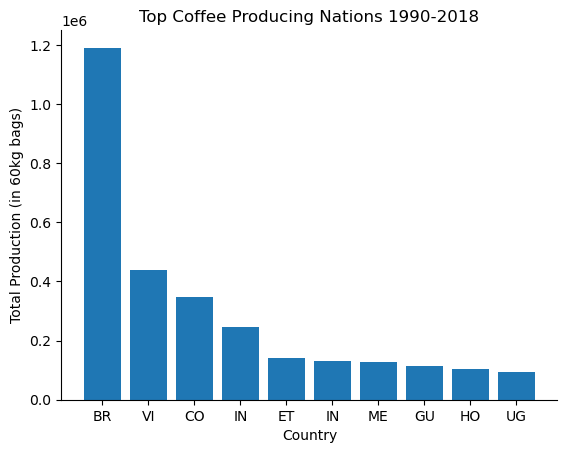

In [36]:
fig, ax = plt.subplots()

ax.set_title('Top Coffee Producing Nations 1990-2018')
ax.set_ylabel('Total Production (in 60kg bags)')
ax.set_xlabel('Country')

ax.bar(
    top10_producers.index,
    top10_producers.values
)

ax.set_xticklabels(([label[:2].upper() for label in top10_producers.index]))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# Top 5 over time

* Create a line chart with the top 5 nations over time. Make sure to include a legend! Consider converting the index to datetime64[ns].

In [22]:
top5_countries = coffee_production.sum().sort_values(ascending=False).head(5).index

top5 = coffee_production[top5_countries]

top5.head()

total_production,Brazil,Viet Nam,Colombia,Indonesia,Ethiopia
1990,27285.6286,1310.288,14396.0,7441.383,2909.451
1991,27293.4934,1437.848,17980.397,8493.196,2924.664
1992,34603.3542,2340.447,14946.878,5569.478,1825.171
1993,28166.9786,3020.216,11422.422,6743.288,2967.004
1994,28192.047,3631.609,12964.0,5367.878,2762.73


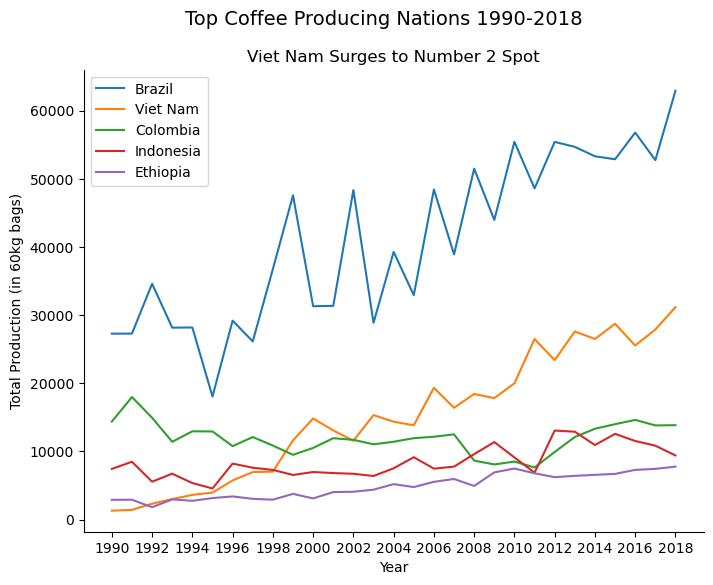

In [137]:
fig, ax = plt.subplots(figsize=(8,6))

fig.suptitle("Top Coffee Producing Nations 1990-2018", fontsize=14)

ax.set_title("Viet Nam Surges to Number 2 Spot")
ax.set_ylabel('Total Production (in 60kg bags)')
ax.set_xlabel('Year')

ax.plot(
    top5.index,
    top5[['Brazil', 'Viet Nam', 'Colombia', 'Indonesia', 'Ethiopia']]
)
ax.spines[['top', 'right']].set_visible(False)

years = top5.index[::2]
ax.set_xticks(years)

ax.legend(top5.columns)

plt.show()

# COMPOSITION OVER TIME

Our client is interested in looking at how Brazil's share of global coffee production has changed over time.

Build a plot that global total production as well as Brazil's contribution to global production over time.

In [44]:
brazil = coffee_production[['Brazil']]
brazil.head()

total_production,Brazil
1990,27285.6286
1991,27293.4934
1992,34603.3542
1993,28166.9786
1994,28192.047


In [51]:
rest_of_world = coffee_production.drop(columns=['Brazil']).sum(axis=1)

rest_of_world_df = rest_of_world.to_frame(name='rest_of_world')
rest_of_world_df.head()

,rest_of_world
1990,65944.431
1991,73973.191
1992,63922.545
1993,63597.643
1994,65121.147


In [52]:
brazil_vs_others = pd.concat([brazil, rest_of_world_df], axis=1)

brazil_vs_others.head()

,Brazil,rest_of_world
1990,27285.6286,65944.431
1991,27293.4934,73973.191
1992,34603.3542,63922.545
1993,28166.9786,63597.643
1994,28192.047,65121.147


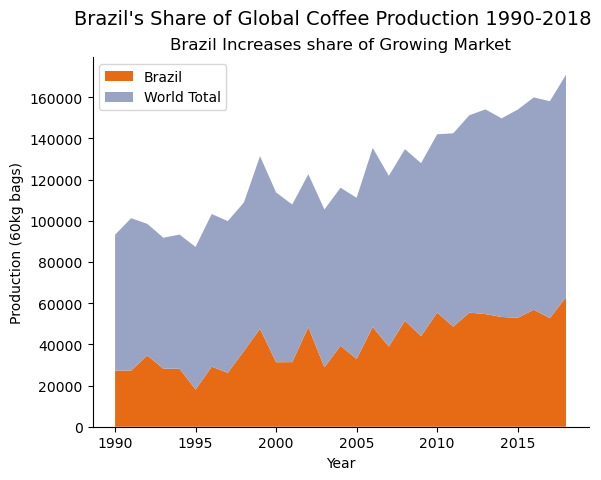

In [60]:
fig, ax = plt.subplots()

fig.suptitle("Brazil's Share of Global Coffee Production 1990-2018", fontsize=14)
ax.set_title("Brazil Increases share of Growing Market")

ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Production (60kg bags)')
ax.set_xlabel('Year')

# Convert columns to float for plotting
brazil_numeric = brazil_vs_others['Brazil'].astype(float)
rest_of_world_numeric = brazil_vs_others['rest_of_world'].astype(float)

ax.stackplot(
    brazil_vs_others.index,
    brazil_numeric,
    rest_of_world_numeric,
    labels=['Brazil', 'World Total'],
    colors=["#E66B14", "#99A4C4"]
)

ax.set_xticks(brazil_vs_others.index[::5])

ax.legend(loc='upper left')
plt.show()

## PRODUCTION RELATIONSHIPS

We want to explore how Brazil compares to its competitors in terms of production. Build a scatterplot  comparing Brazil Vs. VietNam Production and one comparing Brazil to Venezuela.

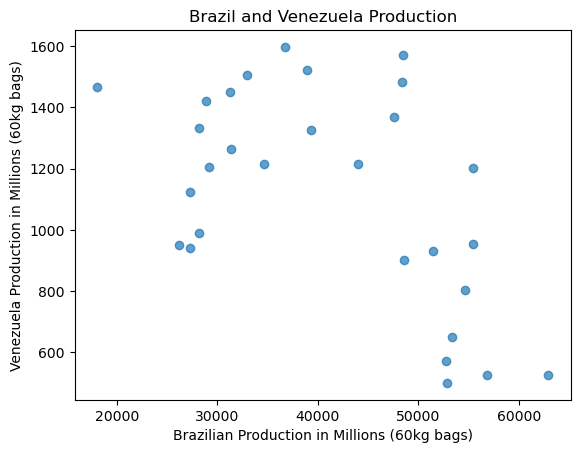

In [66]:
fig, ax = plt.subplots()

ax.set_title("Brazil and Venezuela Production")
ax.set_xlabel('Brazilian Production in Millions (60kg bags)')
ax.set_ylabel('Venezuela Production in Millions (60kg bags)')

ax.scatter(
    coffee_production['Brazil'].astype(float),
    coffee_production['Venezuela'].astype(float),
    alpha=0.7
)

plt.show()

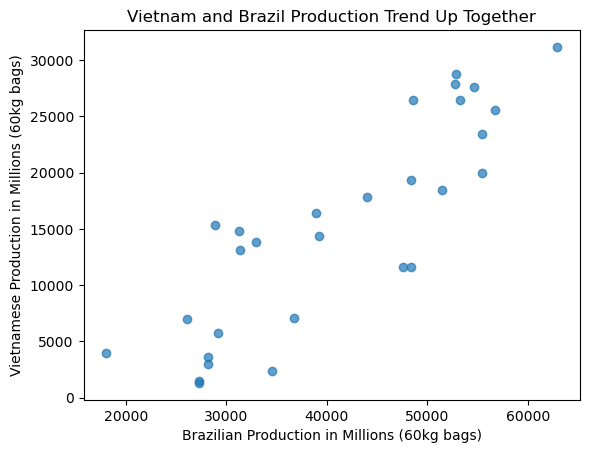

In [65]:
fig, ax = plt.subplots()

ax.set_title("Vietnam and Brazil Production Trend Up Together")
ax.set_xlabel('Brazilian Production in Millions (60kg bags)')
ax.set_ylabel('Vietnamese Production in Millions (60kg bags)')

ax.scatter(
    coffee_production['Brazil'].astype(float),
    coffee_production['Viet Nam'].astype(float),
    alpha=0.7
)

plt.show()

# COMPOSITION OF COFFEE PRODUCTION

* Create a Pie chart with the top 5 producers, as well as the sum for the rest of countries.

* Finally, create two donut charts, one representing Brazil's share of global production in 1990, and one for Brazil's share in 2018.

In [77]:
melted = coffee_production.reset_index().melt(id_vars='index', var_name='Country', value_name='Production')
melted = melted.rename(columns={'index': 'Year'})
melted.head()

,Year,Country,Production
0,1990,Angola,50.345
1,1991,Angola,79.331
2,1992,Angola,77.52
3,1993,Angola,32.608
4,1994,Angola,76.802


In [93]:
coffee_production_2018= (
	melted[melted['Year'] == '2018']
	.groupby('Country')['Production']
	.sum()
    .sort_values(ascending=False)
)

coffee_production_2018_top5 = coffee_production_2018.iloc[:5]

coffee_production_2018_top5

Country
Brazil       62924.8836
Viet Nam     31174.0742
Colombia      13857.962
Indonesia     9417.5942
Ethiopia      7776.2234
Name: Production, dtype: object

In [94]:
coffee_production_rest_of_world = coffee_production_2018[5:].sum()

coffee_production_rest_of_world

45786.00029999999

In [138]:

rest_of_world_series = pd.Series([coffee_production_rest_of_world], index=['Rest of World'])

coffee_production_2018_top5_rest_of_world = pd.concat([coffee_production_2018_top5, rest_of_world_series])

coffee_production_2018_top5_rest_of_world

Brazil           62924.8836
Viet Nam         31174.0742
Colombia          13857.962
Indonesia         9417.5942
Ethiopia          7776.2234
Rest of World    45786.0003
dtype: object

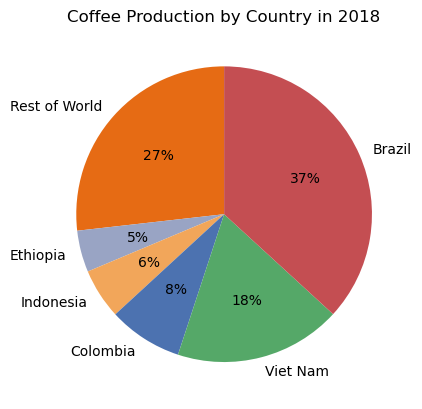

In [139]:
fig, ax = plt.subplots()

ax.set_title("Coffee Production by Country in 2018")

ax.pie(
    coffee_production_2018_top5_rest_of_world [::-1],
    labels=coffee_production_2018_top5_rest_of_world.index[::-1],
    autopct='%0.0f%%',
    startangle=90,
    colors=['#E66B14', '#99A4C4', '#F2A65A', '#4C72B0', '#55A868', '#C44E52']
)

plt.show()

In [140]:
brazil_vs_others = (
    coffee_production
    .assign(
        rest_of_world = coffee_production.drop(columns=['Brazil']).sum(axis=1)
    )
    .loc[:, ['Brazil', 'rest_of_world']]
    .astype({'Brazil': 'float64', 'rest_of_world': 'float64'}
)
)

brazil_vs_others.head()

total_production,Brazil,rest_of_world
1990,27285.6286,65944.431
1991,27293.4934,73973.191
1992,34603.3542,63922.545
1993,28166.9786,63597.643
1994,28192.0470,65121.147


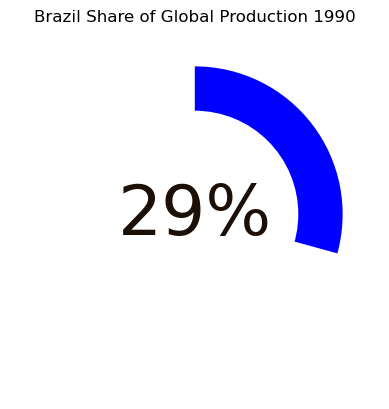

In [148]:
fig, ax = plt.subplots()

ax.set_title("Brazil Share of Global Production 1990")

ax.pie(
    brazil_vs_others.loc['1990'].sort_values(ascending=False),
    startangle=90,
    labels=["",""],
   # autopct='%0.0f%%',
    pctdistance=0.85,
    colors=['White', 'Blue']
)

hole = plt.Circle( (0,0), 0.70, fc='white')
fig = plt.gcf()

fig.gca().add_artist(hole)

plt.text(
    0, 0, f"{brazil_vs_others.loc['1990', 'Brazil'] / brazil_vs_others.loc['1990'].sum() * 100:0.0f}%",
    horizontalalignment='center',
    verticalalignment='center',
    fontsize=50,
    color="#1C0F06"
)



plt.show()

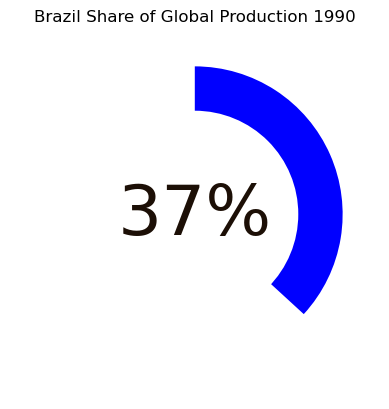

In [149]:
fig, ax = plt.subplots()

ax.set_title("Brazil Share of Global Production 1990")

ax.pie(
    brazil_vs_others.loc['2018'].sort_values(ascending=False),
    startangle=90,
    labels=["",""],
   # autopct='%0.0f%%',
    pctdistance=0.85,
    colors=['White', 'Blue']
)

hole = plt.Circle( (0,0), 0.70, fc='white')
fig = plt.gcf()

fig.gca().add_artist(hole)

plt.text(
    0, 0, f"{brazil_vs_others.loc['2018', 'Brazil'] / brazil_vs_others.loc['2018'].sum() * 100:0.0f}%",
    horizontalalignment='center',
    verticalalignment='center',
    fontsize=50,
    color="#1C0F06"
)



plt.show()

# Coffee Consumption Vs. Prices

Compare coffee prices with coffee consumption in the following countries. 

Is there a relationship between coffee consumption and the price these countries pay?

Plot a dual axis bar chart of price vs consumption totals for these countries.

In [185]:
consumption = pd.read_csv("imports.csv").set_index('imports').mean(axis=1)

consumption.name = 'imports'

consumption.head()

imports
   Austria               1551.083333
   Belgium               4639.533333
   Belgium/Luxembourg    2329.444444
   Bulgaria               397.250000
   Croatia                349.136364
Name: imports, dtype: float64

In [186]:
prices = pd.read_csv("retail-prices.csv").set_index('retail_prices').mean(axis=1)
prices.name = 'retail_prices'

prices.head()

retail_prices
   Austria    11.571135
   Cyprus     10.437695
   Denmark    10.494025
   Finland     7.211692
   France      6.850879
Name: retail_prices, dtype: float64

In [190]:
price_cons = (
    pd.DataFrame(prices)
    .merge(
        pd.DataFrame(consumption),
        left_on=prices.index,
        right_on=consumption.index,
        how='inner'
    )
    .sort_values(by='imports', ascending=False)
)

price_cons.columns = ['country', 'Price', 'Imports']

price_cons['country'] = price_cons['country'].str.strip(' ')
price_cons

,country,Price,Imports
5,Germany,9.515110,16357.666667
11,Japan,21.472939,6862.275235
6,Italy,14.199589,6696.958333
4,France,6.850879,6512.458333
9,Spain,8.029992,4046.291667
7,Netherlands,8.931263,2928.125000
10,Sweden,8.054350,1620.625000
0,Austria,11.571135,1551.083333
3,Finland,7.211692,1157.541667
2,Denmark,10.494025,991.791667


In [191]:
price_cons

,country,Price,Imports
5,Germany,9.515110,16357.666667
11,Japan,21.472939,6862.275235
6,Italy,14.199589,6696.958333
4,France,6.850879,6512.458333
9,Spain,8.029992,4046.291667
7,Netherlands,8.931263,2928.125000
10,Sweden,8.054350,1620.625000
0,Austria,11.571135,1551.083333
3,Finland,7.211692,1157.541667
2,Denmark,10.494025,991.791667


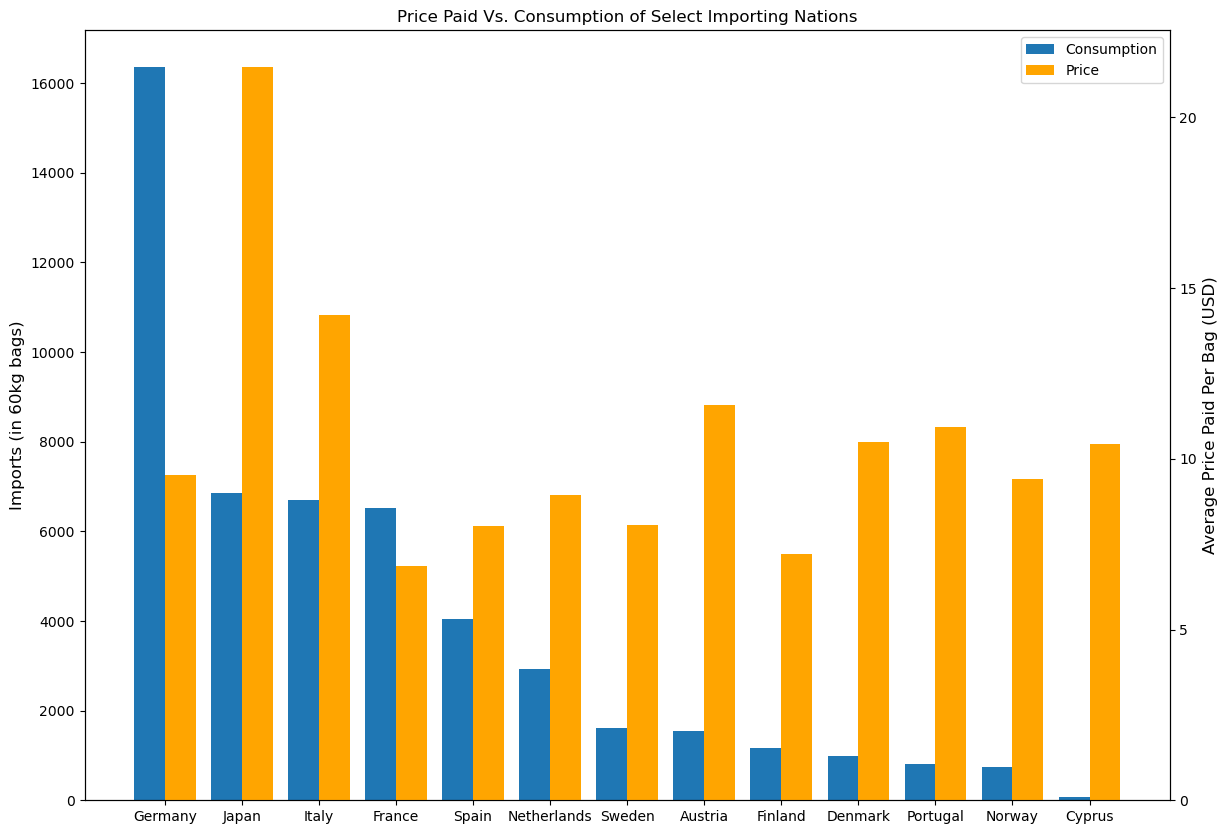

In [194]:

fig, ax = plt.subplots(figsize=(14,10))

width = 0.4
x = np.arange(len(price_cons['country']))

bar1 = ax.bar(
    x-width/2,
    price_cons['Imports'],
    width=width
)

ax.set_title('Price Paid Vs. Consumption of Select Importing Nations')
ax.set_ylabel('Imports (in 60kg bags)', fontsize=12)

ax2 = ax.twinx()

bar2 = ax2.bar(
    x+width/2,
    price_cons['Price'],
    width=width,
    color='orange'
)
ax2.set_ylabel('Average Price Paid Per Bag (USD)', fontsize=12)

plt.xticks(x, price_cons['country'], fontsize=7)
ax.legend([bar1, bar2], ['Consumption', 'Price'])

plt.show()